In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('../data/household_power_consumption.txt',sep=';')

C:\Users\Kartik\AppData\Local\Temp\ipykernel_18376\63241992.py:1: DtypeWarning: Columns (2: Global_active_power, 3: Global_reactive_power, 4: Voltage, 5: Global_intensity, 6: Sub_metering_1, 7: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/household_power_consumption.txt',sep=';')


In [3]:
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


<h2>Basic Data Evaluation</h2>

In [4]:
data.shape

(2075259, 9)

In [5]:
data.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(6), str(2)
memory usage: 142.5+ MB


In [7]:
data.columns=data.columns.str.lower().str.strip()

In [8]:
data.isna().sum()

date                         0
time                         0
global_active_power          0
global_reactive_power        0
voltage                      0
global_intensity             0
sub_metering_1               0
sub_metering_2               0
sub_metering_3           25979
dtype: int64

In [9]:
data['global_active_power']

0          4.216
1          5.360
2          5.374
3          5.388
4          3.666
           ...  
2075254    0.946
2075255    0.944
2075256    0.938
2075257    0.934
2075258    0.932
Name: global_active_power, Length: 2075259, dtype: object

In [10]:
data[data['sub_metering_3'].isna()]

,date,time,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
6839,21/12/2006,11:23:00,?,?,?,?,?,?,NaN
6840,21/12/2006,11:24:00,?,?,?,?,?,?,NaN
19724,30/12/2006,10:08:00,?,?,?,?,?,?,NaN
19725,30/12/2006,10:09:00,?,?,?,?,?,?,NaN
41832,14/1/2007,18:36:00,?,?,?,?,?,?,NaN
...,...,...,...,...,...,...,...,...,...
1990185,28/9/2010,19:09:00,?,?,?,?,?,?,NaN
1990186,28/9/2010,19:10:00,?,?,?,?,?,?,NaN
1990187,28/9/2010,19:11:00,?,?,?,?,?,?,NaN
1990188,28/9/2010,19:12:00,?,?,?,?,?,?,NaN


In [11]:
data.eq('?').sum()

date                         0
time                         0
global_active_power      25979
global_reactive_power    25979
voltage                  25979
global_intensity         25979
sub_metering_1           25979
sub_metering_2           25979
sub_metering_3               0
dtype: int64

In [12]:
data=data.replace('?',np.nan)

In [13]:
data.isna().sum()

date                         0
time                         0
global_active_power      25979
global_reactive_power    25979
voltage                  25979
global_intensity         25979
sub_metering_1           25979
sub_metering_2           25979
sub_metering_3           25979
dtype: int64

In [14]:
data[data['global_active_power'].isna()][['date','time']].head(20)

,date,time
6839,21/12/2006,11:23:00
6840,21/12/2006,11:24:00
19724,30/12/2006,10:08:00
19725,30/12/2006,10:09:00
41832,14/1/2007,18:36:00
61909,28/1/2007,17:13:00
98254,22/2/2007,22:58:00
98255,22/2/2007,22:59:00
142588,25/3/2007,17:52:00
190497,28/4/2007,00:21:00


In [15]:
missing = data["global_active_power"].isna()

groups = missing.ne(missing.shift()).cumsum()

block_sizes = missing.groupby(groups).sum()

missing_blocks = block_sizes[block_sizes > 0]

print(missing_blocks)
print("Largest missing block:", missing_blocks.max())

global_active_power
2         2
4         2
6         1
8         1
10        2
       ... 
134       1
136       1
138    7226
140    5237
142       1
Name: global_active_power, Length: 71, dtype: int64
Largest missing block: 7226


In [16]:
missing_blocks.sort_values(ascending=False).head(15)

global_active_power
138    7226
140    5237
14     3723
100    3305
118    3129
126    2027
104     891
32       83
78       70
34       47
70       43
84       38
26       33
88       24
38       21
Name: global_active_power, dtype: int64

In [17]:
missing_rows= data[data['global_active_power'].isna()]

In [18]:
missing_rows[['date','time']].head(20)

,date,time
6839,21/12/2006,11:23:00
6840,21/12/2006,11:24:00
19724,30/12/2006,10:08:00
19725,30/12/2006,10:09:00
41832,14/1/2007,18:36:00
61909,28/1/2007,17:13:00
98254,22/2/2007,22:58:00
98255,22/2/2007,22:59:00
142588,25/3/2007,17:52:00
190497,28/4/2007,00:21:00


In [19]:
numeric_cols = [
    "global_active_power",
    "global_reactive_power",
    "voltage",
    "global_intensity",
    "sub_metering_1",
    "sub_metering_2",
    "sub_metering_3"
]

In [20]:
data[numeric_cols]=data[numeric_cols].apply(pd.to_numeric,errors='coerce')

In [21]:
data.head()

,date,time,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   date                   str    
 1   time                   str    
 2   global_active_power    float64
 3   global_reactive_power  float64
 4   voltage                float64
 5   global_intensity       float64
 6   sub_metering_1         float64
 7   sub_metering_2         float64
 8   sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [23]:
data[numeric_cols].isna().sum()

global_active_power      25979
global_reactive_power    25979
voltage                  25979
global_intensity         25979
sub_metering_1           25979
sub_metering_2           25979
sub_metering_3           25979
dtype: int64

In [24]:
data['date_time']=pd.to_datetime(data['date']+" "+data['time'])

C:\Users\Kartik\AppData\Local\Temp\ipykernel_18376\2208523486.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['date_time']=pd.to_datetime(data['date']+" "+data['time'])


In [25]:
data.head()

,date,time,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,date_time
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [26]:
col=data.pop('date_time')
data.insert(2,'date_time',col)

In [27]:
data['date_time'].isna().sum()

np.int64(0)

In [28]:
data['hour']=data['date_time'].dt.hour

In [29]:
data['day_of_week']=data['date_time'].dt.day_of_week

In [30]:
data['month']=data['date_time'].dt.month

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 13 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   date                   str           
 1   time                   str           
 2   date_time              datetime64[us]
 3   global_active_power    float64       
 4   global_reactive_power  float64       
 5   voltage                float64       
 6   global_intensity       float64       
 7   sub_metering_1         float64       
 8   sub_metering_2         float64       
 9   sub_metering_3         float64       
 10  hour                   int32         
 11  day_of_week            int32         
 12  month                  int32         
dtypes: datetime64[us](1), float64(7), int32(3), str(2)
memory usage: 182.1 MB


In [32]:
#setting date time as index
data = data.set_index("date_time")

In [33]:
data.head()

,date,time,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,hour,day_of_week,month
date_time,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5,12
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5,12
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5,12
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,5,12
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,5,12


In [34]:
data.index.is_monotonic_increasing

True

In [35]:
print(data.index.is_monotonic_increasing)
print(data.index.min())
print(data.index.max())

True
2006-12-16 17:24:00
2010-11-26 21:02:00


<h3>Feature Engineering</h3>

In [36]:
data['year']=data.index.year

In [37]:
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

In [38]:
data[[
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]].head()

,hour,day_of_week,month,year,is_weekend
date_time,,,,,
2006-12-16 17:24:00,17,5,12,2006,1
2006-12-16 17:25:00,17,5,12,2006,1
2006-12-16 17:26:00,17,5,12,2006,1
2006-12-16 17:27:00,17,5,12,2006,1
2006-12-16 17:28:00,17,5,12,2006,1


In [39]:
data[[
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]].nunique()

hour           24
day_of_week     7
month          12
year            5
is_weekend      2
dtype: int64

In [40]:
data["lag_1"] = data["global_active_power"].shift(1)
data["lag_5"] = data["global_active_power"].shift(5)
data["lag_15"] = data["global_active_power"].shift(15)
data["lag_60"] = data["global_active_power"].shift(60)

In [41]:
data[data['global_active_power'].isna()][['global_active_power','lag_1','lag_5','lag_15','lag_60']]

,global_active_power,lag_1,lag_5,lag_15,lag_60
date_time,,,,,
2006-12-21 11:23:00,NaN,0.244,0.242,0.394,1.488
2006-12-21 11:24:00,NaN,NaN,0.244,0.338,1.490
2006-12-30 10:08:00,NaN,6.218,9.078,6.808,1.896
2006-12-30 10:09:00,NaN,NaN,8.176,6.826,2.142
2007-01-14 18:36:00,NaN,3.222,3.150,2.806,4.984
...,...,...,...,...,...
2010-09-28 19:09:00,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:10:00,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:11:00,NaN,NaN,NaN,NaN,NaN


In [42]:
data["rolling_mean_15"] = (
    data["global_active_power"]
    .shift(1)
    .rolling(15)
    .mean()
)

In [43]:
data["rolling_mean_60"] = (
    data["global_active_power"]
    .shift(1)
    .rolling(60)
    .mean()
)

In [44]:
data[[
    "global_active_power",
    "lag_1",
    "lag_15",
    "lag_60",
    "rolling_mean_15",
    "rolling_mean_60"
]].iloc[60:80]

,global_active_power,lag_1,lag_15,lag_60,rolling_mean_15,rolling_mean_60
date_time,,,,,,
2006-12-16 18:24:00,3.452,2.926,4.464,4.216,3.450133,4.103600
2006-12-16 18:25:00,4.870,3.452,3.396,5.360,3.382667,4.090867
2006-12-16 18:26:00,4.868,4.870,3.090,5.374,3.480933,4.082700
2006-12-16 18:27:00,4.866,4.868,3.730,5.388,3.599467,4.074267
2006-12-16 18:28:00,3.176,4.866,2.308,3.666,3.675200,4.065567
2006-12-16 18:29:00,2.920,3.176,2.388,3.520,3.733067,4.057400
2006-12-16 18:30:00,2.930,2.920,4.598,3.702,3.768533,4.047400
2006-12-16 18:31:00,2.912,2.930,4.524,3.700,3.657333,4.034533
2006-12-16 18:32:00,2.608,2.912,4.202,3.668,3.549867,4.021400


In [45]:
data.isna().sum()

date                         0
time                         0
global_active_power      25979
global_reactive_power    25979
voltage                  25979
global_intensity         25979
sub_metering_1           25979
sub_metering_2           25979
sub_metering_3           25979
hour                         0
day_of_week                  0
month                        0
year                         0
is_weekend                   0
lag_1                    25980
lag_5                    25984
lag_15                   25994
lag_60                   26039
rolling_mean_15          26970
rolling_mean_60          30081
dtype: int64

In [46]:
data.shape

(2075259, 20)

<h3>Feature Selection </h3>

In [47]:
model_data = data[
    [
        "global_active_power",
        "hour",
        "day_of_week",
        "month",
        "year",
        "is_weekend",
        "lag_1",
        "lag_5",
        "lag_15",
        "lag_60",
        "rolling_mean_15",
        "rolling_mean_60"
    ]
].copy()

In [48]:
model_data.head()

,global_active_power,hour,day_of_week,month,year,is_weekend,lag_1,lag_5,lag_15,lag_60,rolling_mean_15,rolling_mean_60
date_time,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,17,5,12,2006,1,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-16 17:25:00,5.360,17,5,12,2006,1,4.216,NaN,NaN,NaN,NaN,NaN
2006-12-16 17:26:00,5.374,17,5,12,2006,1,5.360,NaN,NaN,NaN,NaN,NaN
2006-12-16 17:27:00,5.388,17,5,12,2006,1,5.374,NaN,NaN,NaN,NaN,NaN
2006-12-16 17:28:00,3.666,17,5,12,2006,1,5.388,NaN,NaN,NaN,NaN,NaN


In [49]:
model_data.dropna(inplace=True)

In [50]:
model_data.isna().sum()

global_active_power    0
hour                   0
day_of_week            0
month                  0
year                   0
is_weekend             0
lag_1                  0
lag_5                  0
lag_15                 0
lag_60                 0
rolling_mean_15        0
rolling_mean_60        0
dtype: int64

In [51]:
print(model_data.shape)
print(model_data.isna().sum())

(2045110, 12)
global_active_power    0
hour                   0
day_of_week            0
month                  0
year                   0
is_weekend             0
lag_1                  0
lag_5                  0
lag_15                 0
lag_60                 0
rolling_mean_15        0
rolling_mean_60        0
dtype: int64


In [52]:
model_data['global_active_power'].describe()

count    2.045110e+06
mean     1.089999e+00
std      1.055840e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.000000e-01
75%      1.528000e+00
max      1.112200e+01
Name: global_active_power, dtype: float64

In [53]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

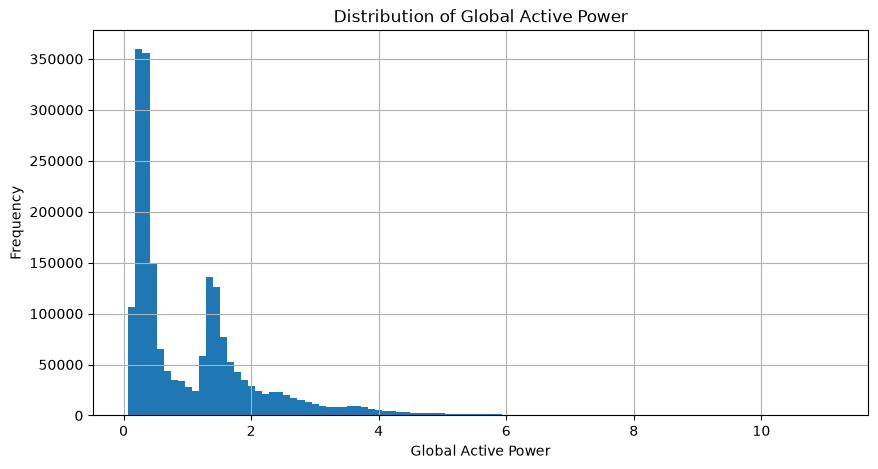

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
model_data["global_active_power"].hist(bins=100)

plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")

plt.show()

In [55]:
hourly_power=model_data.groupby('hour')['global_active_power'].mean()

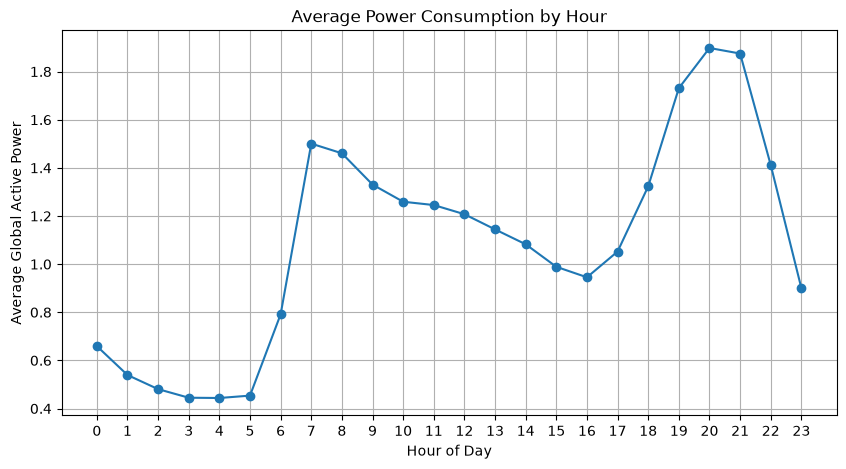

In [56]:
plt.figure(figsize=(10, 5))

hourly_power.plot(kind="line", marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Consumption by Hour")

plt.xticks(range(24))
plt.grid()

plt.show()

In [57]:
model_data.groupby("is_weekend")["global_active_power"].mean()

is_weekend
0    1.034324
1    1.231669
Name: global_active_power, dtype: float64

In [58]:
daily_power = (
    model_data["global_active_power"]
    .resample("D")
    .mean()
)

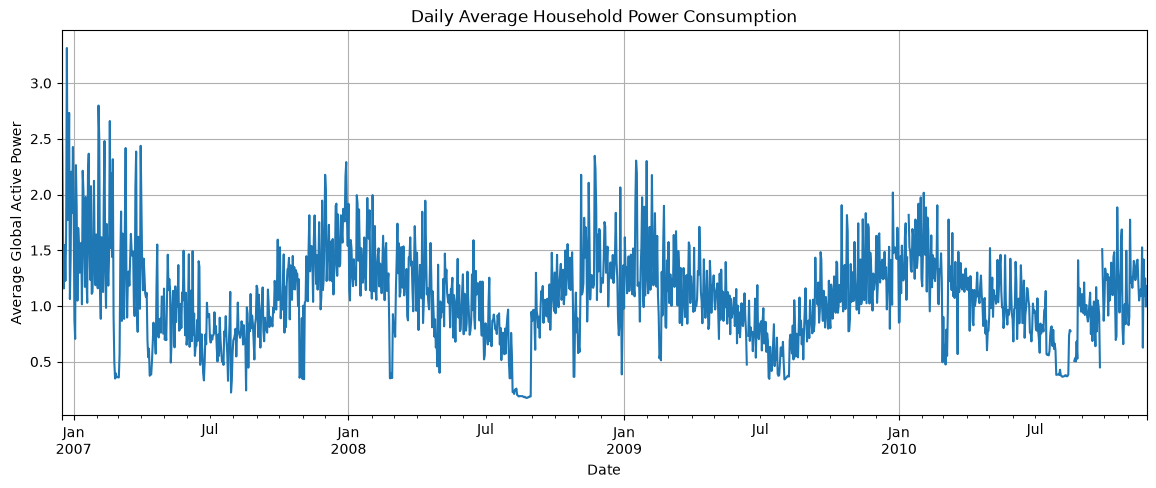

In [59]:
plt.figure(figsize=(14, 5))

daily_power.plot()

plt.xlabel("Date")
plt.ylabel("Average Global Active Power")
plt.title("Daily Average Household Power Consumption")

plt.grid()
plt.show()